# Part 1: Experiment Tracking with MLflow


## Task 1.1: MLflow Setup & Experminet Logging

#### Setting up Experiment

In [2]:
import mlflow
import mlflow.sklearn
import mlflow.pytorch
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import torch
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import torch.optim as optim

mlflow.set_tracking_uri("http://localhost:5001") 
mlflow.set_experiment("taxi-tip-prediction") #

<Experiment: artifact_location='mlflow-artifacts:/1', creation_time=1776383512624, experiment_id='1', last_update_time=1776383512624, lifecycle_stage='active', name='taxi-tip-prediction', tags={}, trace_location=None, workspace='default'>

#### Cleaning Data and Setting Up Helper Functions

In [ ]:
#Evaluation Metric Helper Function
def evaluate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

In [ ]:
#Data Cleaning and Set-up
import pandas as pd
import polars as pl
df = pl.read_parquet("data/freshlyCleaned.parquet")


df = df.with_columns([
   pl.when(pl.col("tip_amount") > pl.col("fare_amount") * 0.20)
   .then(1)
   .otherwise(0)
   .alias("high_tip")
])

feature_cols = [
    'pickup_hour', 'pickup_day_of_week', 'is_weekend', 
    'trip_duration_minutes', 'trip_speed_mph', 'log_trip_distance',
    'fare_per_mile', 'fare_per_minute', 'PU_Borough', 'DO_Borough' 
]


X = df.select(feature_cols).to_pandas()
y_reg = df.select('tip_amount').to_series().to_pandas()
y_clf = df.select('high_tip').to_series().to_pandas()


df_pandas = df.to_pandas()






#### Setting Training Splits like Assignment 2# and Scaling the Data

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

#Training splits in Train: 70 Test: 15 Validation: 15
X_train, X_temp, y_train_clf, y_temp_clf, y_train_reg, y_temp_reg = train_test_split(
    X, y_clf, y_reg, test_size=0.30, random_state=42, stratify=y_clf
)


X_val, X_test, y_val_clf, y_test_clf, y_val_reg, y_test_reg = train_test_split(
    X_temp, y_temp_clf, y_temp_reg, test_size=0.50, random_state=42, stratify=y_temp_clf
)

#
numeric_features = ['pickup_hour', 'pickup_day_of_week', 'trip_duration_minutes', 'trip_speed_mph', 'log_trip_distance', 'fare_per_mile', 'fare_per_minute']
categorical_features = ['PU_Borough', 'DO_Borough', 'is_weekend']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

X_train_scaled = preprocessor.fit_transform(X_train)
X_val_scaled = preprocessor.transform(X_val)
X_test_scaled = preprocessor.transform(X_test)


feature_names = numeric_features + list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features))

In [10]:
import mlflow
import mlflow.sklearn
import joblib
import numpy as np
# Import the required regression metrics 
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set the experiment name as required 
mlflow.set_experiment("taxi-tip-prediction")

# Load your previously saved model
rf_model = joblib.load("RFReg.lib")

with mlflow.start_run(run_name="Random_Forest_Regressor"):
    
    # Log all hyperparameters 
    mlflow.log_params(rf_model.get_params())

    # Generate predictions
    y_pred = rf_model.predict(X_test_scaled)
    
    # Calculate required Regression Metrics 
    mae = mean_absolute_error(y_test_reg, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred))
    r2 = r2_score(y_test_reg, y_pred)

    # Log metrics to MLflow 
    mlflow.log_metrics({
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })
    
    # Add required tags for model type and dataset version [cite: 44]
    mlflow.set_tags({
        "model_type": "RandomForest",
        "dataset_version": "NYC_Taxi_v1.0"
    })
    
    # Log the model artifact using the correct mlflow.sklearn method [cite: 43]
    mlflow.sklearn.log_model(rf_model, "model")

2026/04/17 14:25:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/17 14:25:26 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run Random_Forest_Regressor at: http://localhost:5001/#/experiments/1/runs/0a79bb81792446d5a329b02230aac413
🧪 View experiment at: http://localhost:5001/#/experiments/1


#### Training new NN model as a regression model to predict tip amount instead of high top

In [14]:
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import torch.optim as optim

#Using Mps to for increased speed on my device
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

#Seeting up data as a tensor for torch to do work
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_reg.values, dtype=torch.float32).view(-1, 1)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_reg.values, dtype=torch.float32).view(-1, 1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)

#Creating model class using standard setup
class TipNeuralNet(nn.Module):
    def __init__(self, input_dim):
        super(TipNeuralNet, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32), 
            nn.ReLU(),
            nn.Linear(32, 1)   
        )
        
    def forward(self, x):
        return self.network(x)

model = TipNeuralNet(X_train_scaled.shape[1]).to(device)

# Changed from BCE to MSE since this is predicting tip_amount (Regression) 
criterion = nn.MSELoss() 
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses, val_losses = [], []
epochs = 20

#Creating Mlflow Run For This Model
with mlflow.start_run(run_name="Neural_Network_Tip_Regressor"):

    # Log all relevant hyperparameters 
    mlflow.log_params({
        "learning_rate": 0.001,
        "epochs": epochs,
        "batch_size": 1024,
        "loss_function": "MSELoss",
        "random_state": 42
    })
    
    # Gradient Descent Training loop
    for epoch in range(epochs):
        model.train()
        batch_losses = []
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())
        
        # Validation evaluation step
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val_tensor.to(device))
            val_loss = criterion(val_outputs, y_val_tensor.to(device))
            
        train_losses.append(sum(batch_losses)/len(batch_losses))
        val_losses.append(val_loss.item())
        
        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1}/20 | Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f}")
            
    # Calculate required final metrics on the validation set 
    model.eval()
    with torch.no_grad():
        predictions = model(X_val_tensor.to(device)).cpu().numpy()
        actuals = y_val_tensor.cpu().numpy()
    
    mae = mean_absolute_error(actuals, predictions)
    rmse = np.sqrt(mean_squared_error(actuals, predictions))
    r2 = r2_score(actuals, predictions)

    # Log required metrics: MAE, RMSE, and R2 
    mlflow.log_metrics({
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })
            
    # Log model type and dataset version tags [cite: 44]
    mlflow.set_tags({
        "model_type": "NeuralNetwork", 
        "dataset_version": "NYC_Yellow_Taxi_v1.0"
    })
    
    # Log the trained model artifact [cite: 43]
    mlflow.pytorch.log_model(model, "model")

Using device: mps
🏃 View run Neural_Network_Tip_Regressor at: http://localhost:5001/#/experiments/1/runs/a0af12edf5864870a78f8ceb63daf956
🧪 View experiment at: http://localhost:5001/#/experiments/1


KeyboardInterrupt: 

#### Evaluation Runs

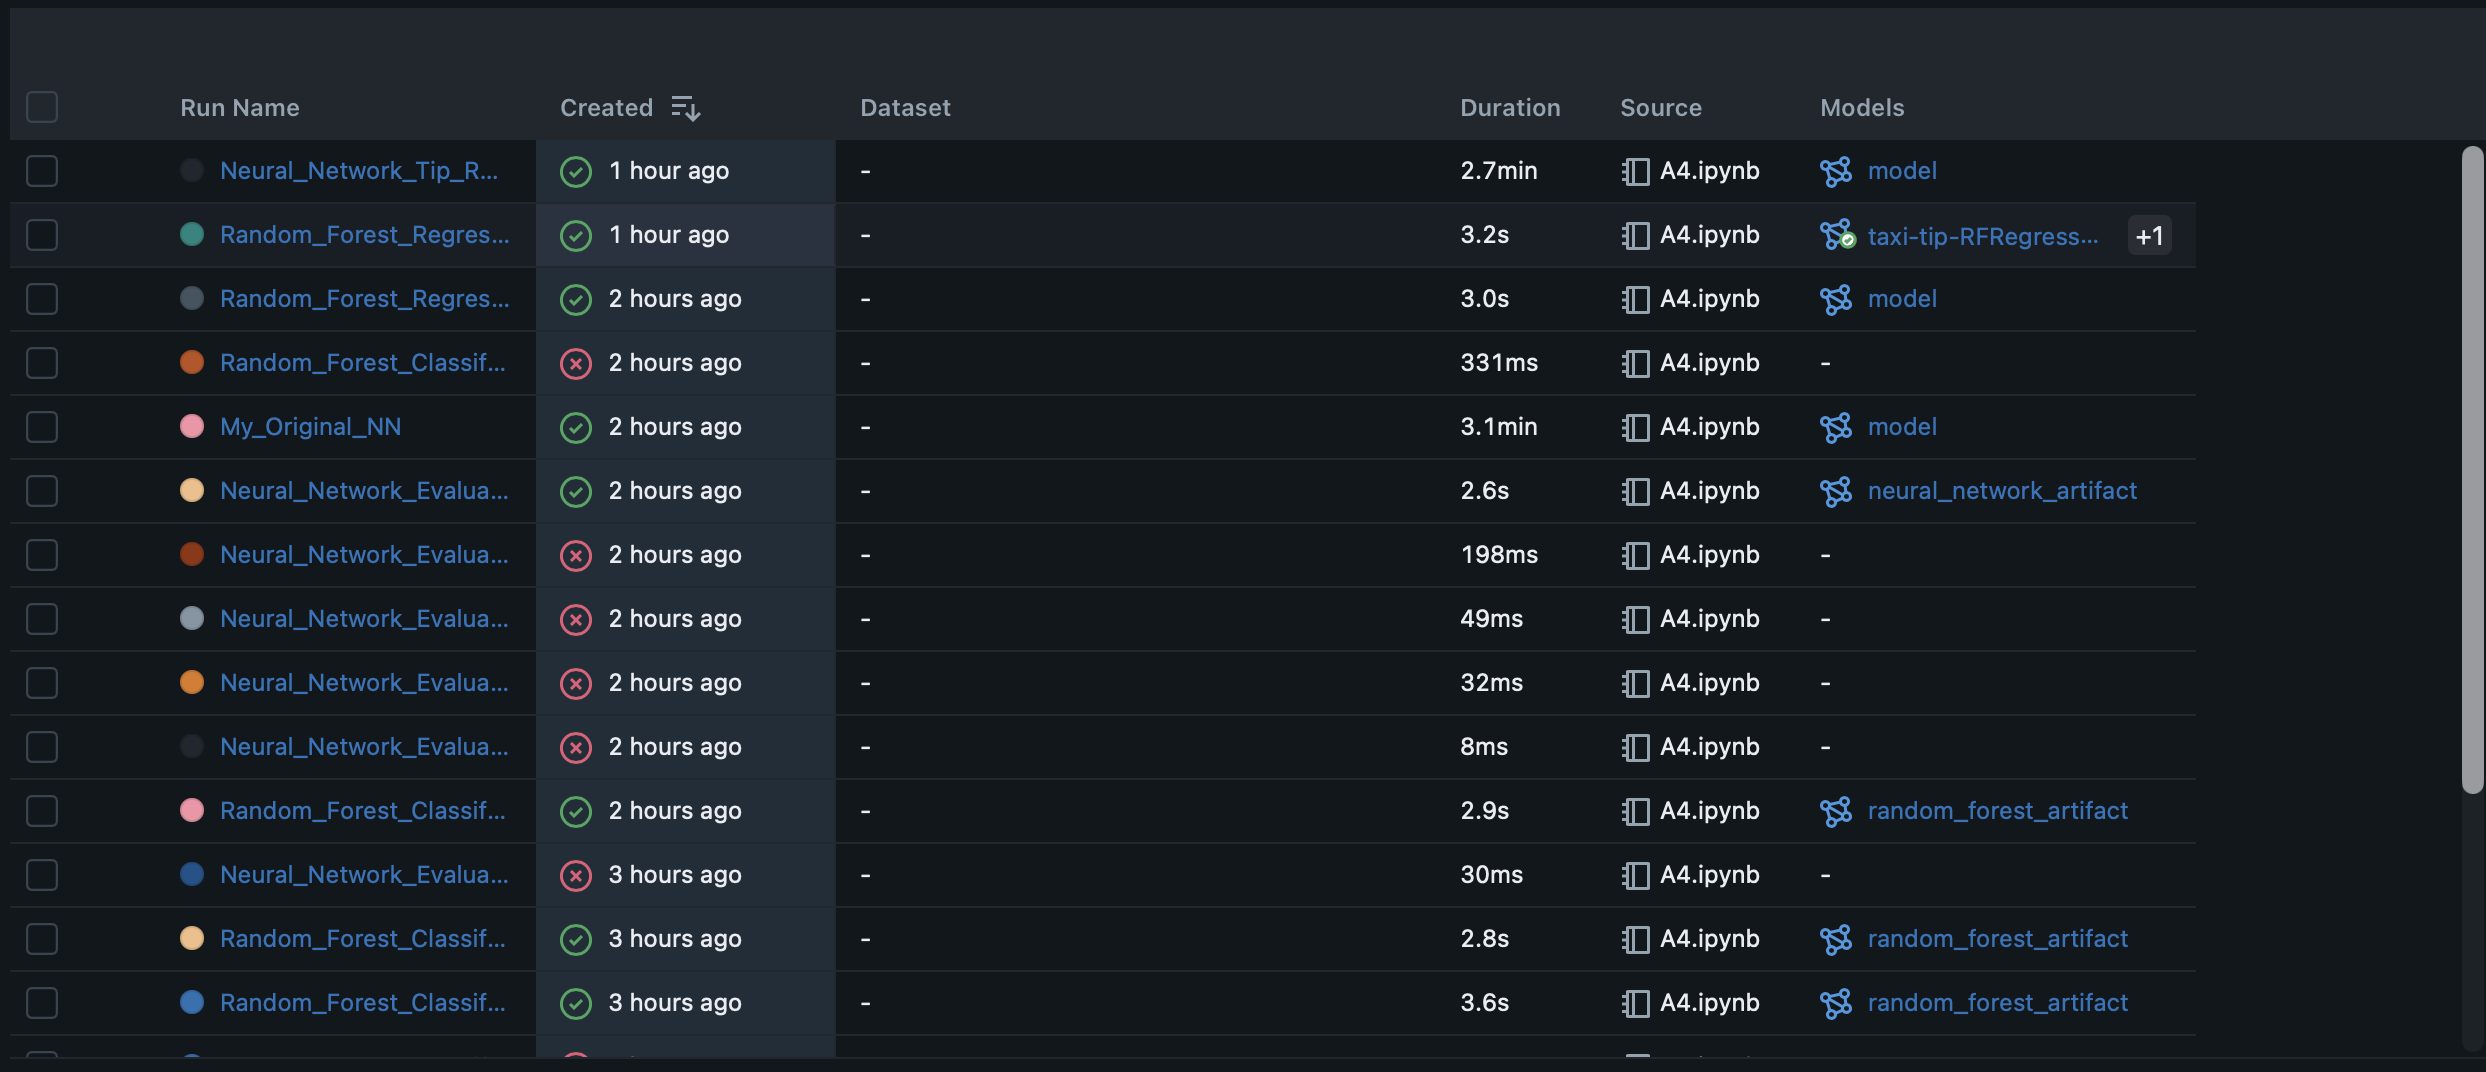

## Task 1.2: Model Comparison & Registry

#### Output for the runs

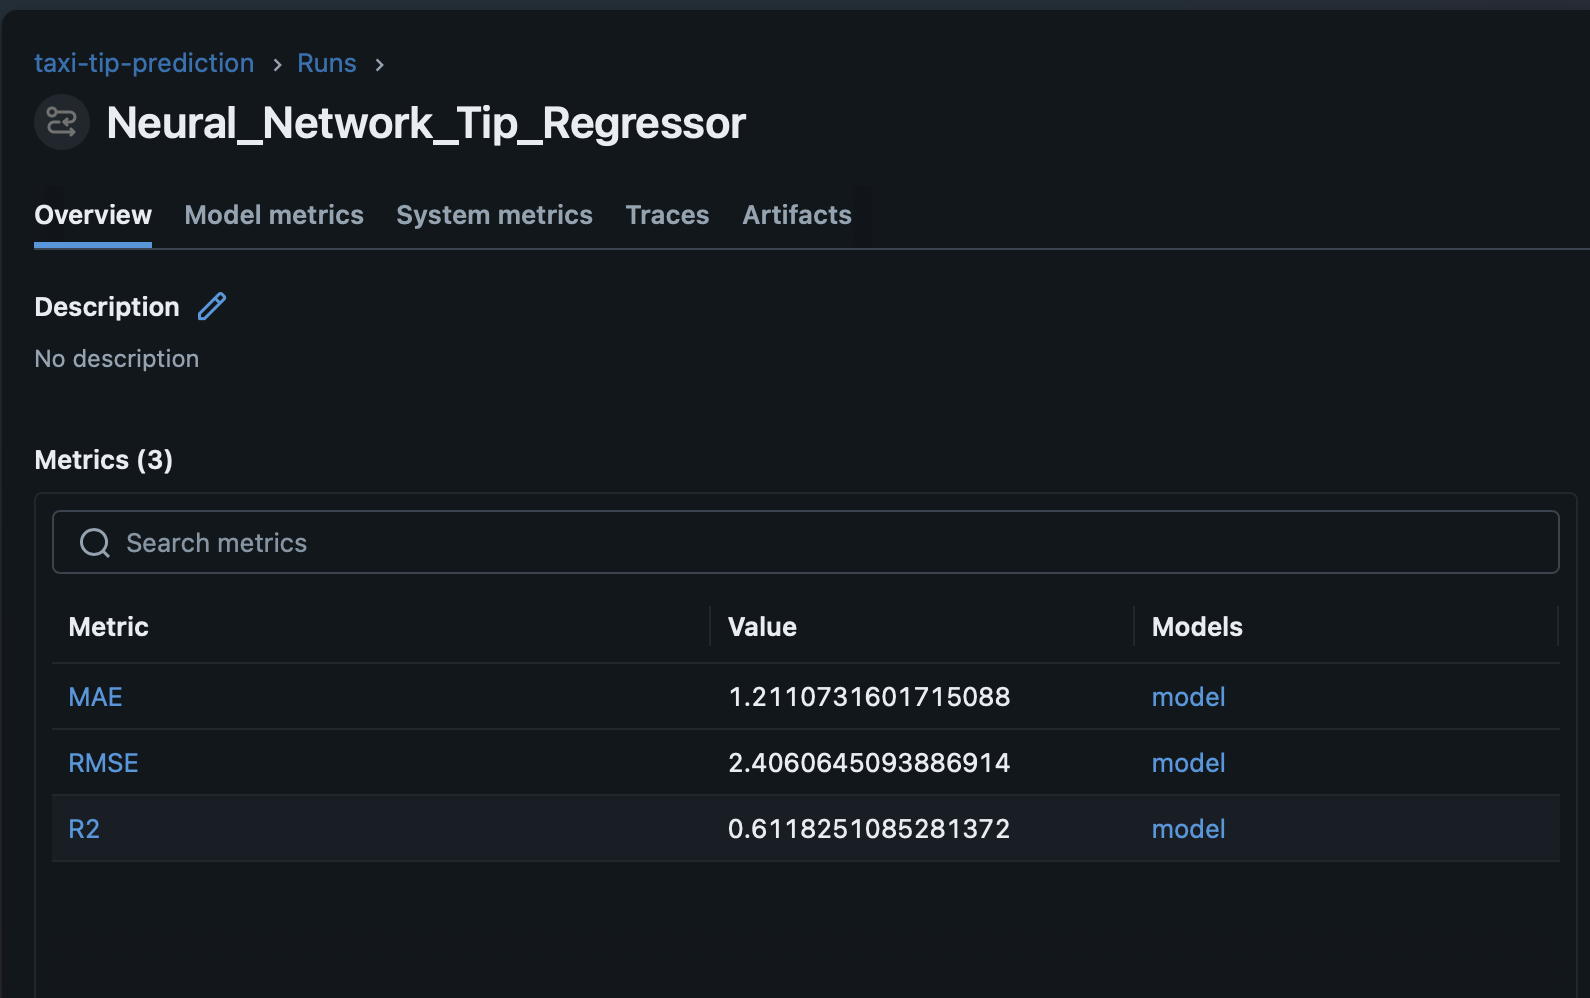
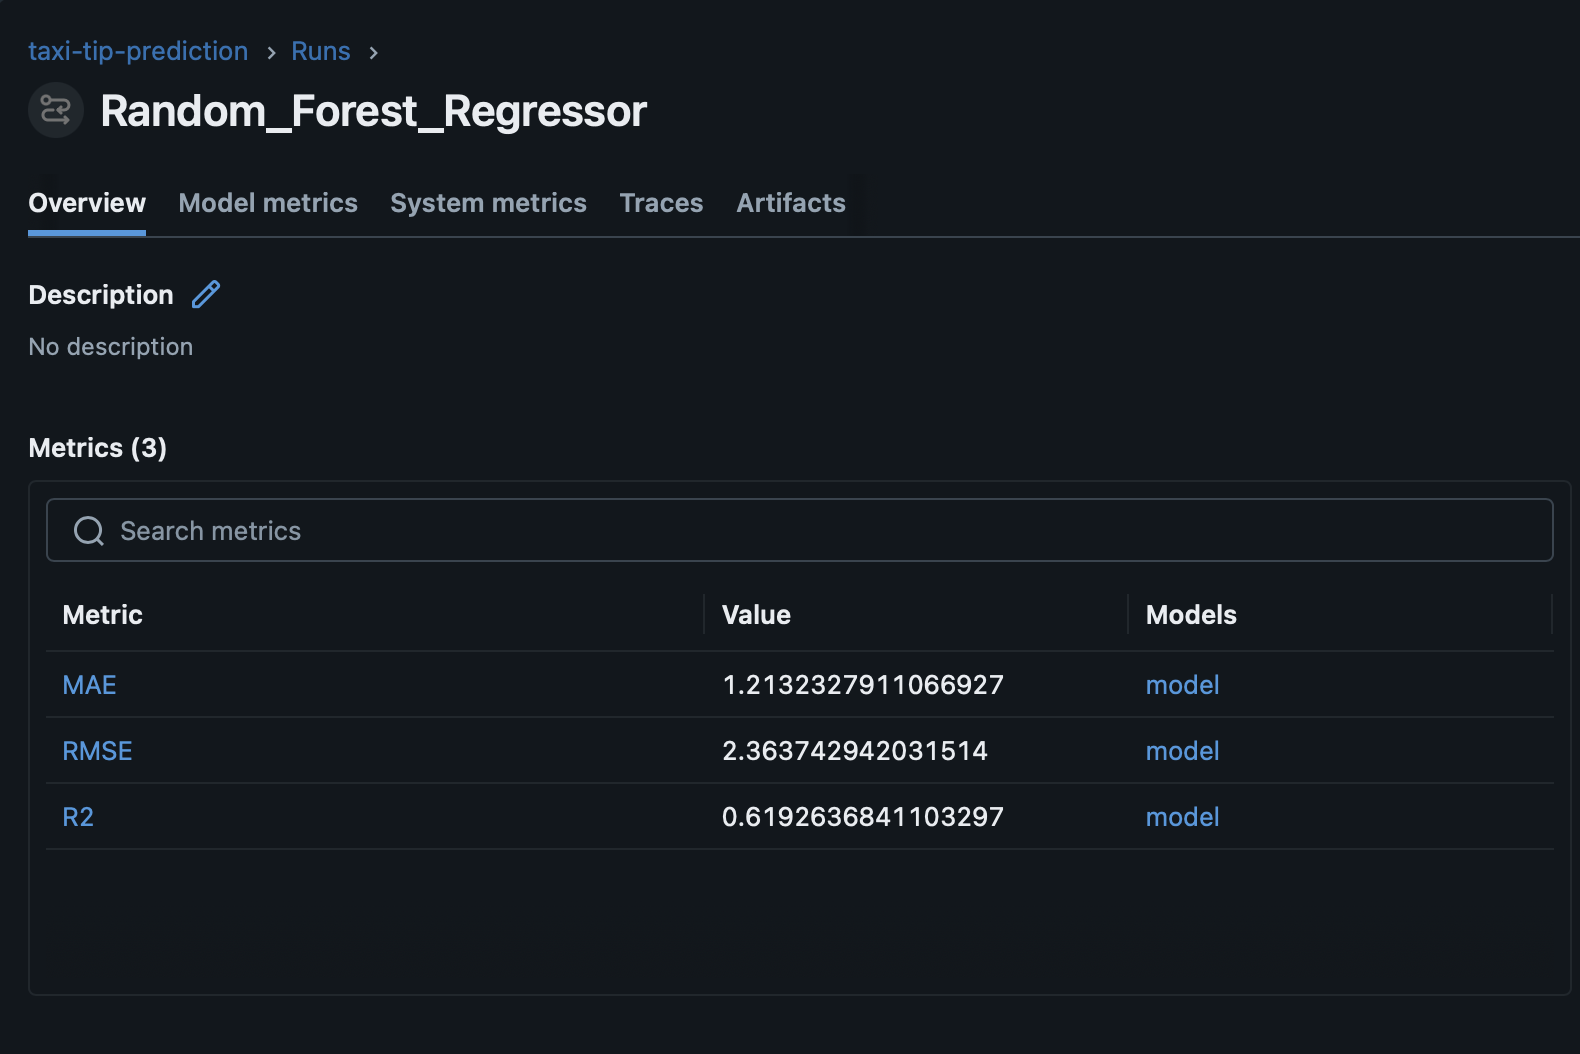
The Random Forest Regressor performed slightly better than the Neural Network, achieving a higher R^2 score of approximately 0.619 compared to the Neural Network's 0.611. While the Neural Network had a marginally lower Mean Absolute Error (MAE), the Random Forest's superior RMSE and R^2 indicate it captures the variance in the taxi tip data more effectively.

This due to the non-normal nature of the NYC Yellow Taxi dataset. Random Forest models are more able to handle extreme outliers which were not all filtered out in Assignment 2. A neural network that is allowed to more depth may provide a more accurate model.

#### Register The Best Performing Model(RF Regression)

In [ ]:
import mlflow
from mlflow.tracking import MlflowClient

#Setup
run_id = "0a79bb81792446d5a329b02230aac413" 
model_name = "taxi-tip-regressor" # Descriptive name as required [cite: 51]
model_uri = f"runs:/{run_id}/model"

mv = mlflow.register_model(model_uri, model_name)

# 3. Add version description documenting performance [cite: 51]
client = MlflowClient()
client.update_model_version(
    name=model_name,
    version=mv.version,
    description="Random Forest Regressor. Metrics: R2=0.619, RMSE=2.36, MAE=1.21. Best performing model."
)

# 4. Demonstrate loading from registry and making a sample prediction [cite: 52]
print(f"\nLoading model '{model_name}' version {mv.version}...")
loaded_model = mlflow.sklearn.load_model(model_uri=f"models:/{model_name}/{mv.version}")

# Perform sample prediction (using first row of your scaled validation data)
sample_input = X_val_scaled[:1]
prediction = loaded_model.predict(sample_input)

print("-" * 30)
print(f"Model successfully loaded from registry!")
print(f"Sample Tip Prediction: ${prediction[0]:.2f}")
print("-" * 30)

Successfully registered model 'taxi-tip-regressor'.
2026/04/17 15:29:46 WARNING mlflow.tracking._model_registry.fluent: Run with id 0a79bb81792446d5a329b02230aac413 has no artifacts at artifact path 'model', registering model based on models:/m-e684d48e470b4412b7cfd3789714dc28 instead
2026/04/17 15:29:46 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: taxi-tip-regressor, version 1
Created version '1' of model 'taxi-tip-regressor'.



Loading model 'taxi-tip-regressor' version 1...
------------------------------
Model successfully loaded from registry!
Sample Tip Prediction: $2.66
------------------------------
